In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("/content/smart_meter_data.csv")
df.head(30)

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label
0,1/1/2024 0:00,0.457786,0.469524,0.396368,0.445441,0.692057,Normal
1,1/1/2024 0:30,0.351956,0.465545,0.451184,0.458729,0.539874,Normal
2,1/1/2024 1:00,0.482948,0.285415,0.408289,0.470360,0.614724,Normal
3,1/1/2024 1:30,0.628838,0.482095,0.512308,0.576241,0.757044,Normal
4,1/1/2024 2:00,0.335974,0.624741,0.672021,0.373004,0.673981,Normal
5,1/1/2024 2:30,0.335977,0.355389,0.382767,0.361111,0.618607,Normal
6,1/1/2024 3:00,0.638202,0.667102,0.643164,0.611004,0.703225,Normal
7,1/1/2024 3:30,0.502906,0.591854,0.381205,0.407144,0.718050,Normal
8,1/1/2024 4:00,0.296754,0.427858,0.371512,0.311121,0.663703,Normal
9,1/1/2024 4:30,0.465427,0.507400,0.616383,0.404446,0.668736,Normal


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             5000 non-null   object 
 1   Electricity_Consumed  5000 non-null   float64
 2   Temperature           5000 non-null   float64
 3   Humidity              5000 non-null   float64
 4   Wind_Speed            5000 non-null   float64
 5   Avg_Past_Consumption  5000 non-null   float64
 6   Anomaly_Label         5000 non-null   object 
dtypes: float64(5), object(2)
memory usage: 273.6+ KB


In [ ]:
df.isnull().sum()

,0
Timestamp,0
Electricity_Consumed,0
Temperature,0
Humidity,0
Wind_Speed,0
Avg_Past_Consumption,0
Anomaly_Label,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Timestamp             5000 non-null   datetime64[ns]
 1   Electricity_Consumed  5000 non-null   float64       
 2   Temperature           5000 non-null   float64       
 3   Humidity              5000 non-null   float64       
 4   Wind_Speed            5000 non-null   float64       
 5   Avg_Past_Consumption  5000 non-null   float64       
 6   Anomaly_Label         5000 non-null   object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 273.6+ KB


In [ ]:
df.describe()

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2024-02-22 01:45:00.000000256,0.376677,0.525069,0.497632,0.464628,0.458738
min,2024-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2024-01-27 00:52:30,0.265349,0.434253,0.398956,0.382906,0.358857
50%,2024-02-22 01:45:00,0.377244,0.524052,0.497539,0.464958,0.457814
75%,2024-03-19 02:37:30,0.486002,0.617281,0.595359,0.547419,0.555607
max,2024-04-14 03:30:00,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,0.164117,0.135603,0.146781,0.120370,0.146749


In [ ]:
df['Anomaly_Label'].value_counts()

,count
Anomaly_Label,
Normal,4750
Abnormal,250


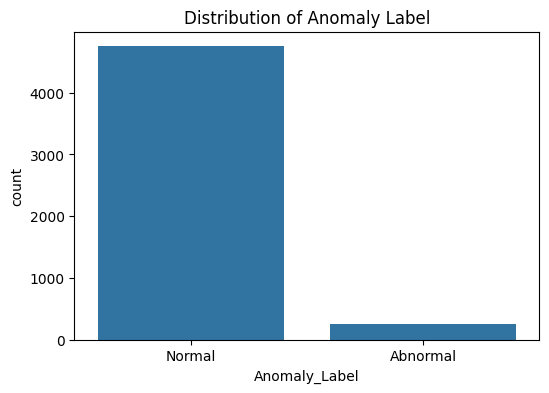

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Anomaly_Label", data=df)
plt.title("Distribution of Anomaly Label")
plt.show()

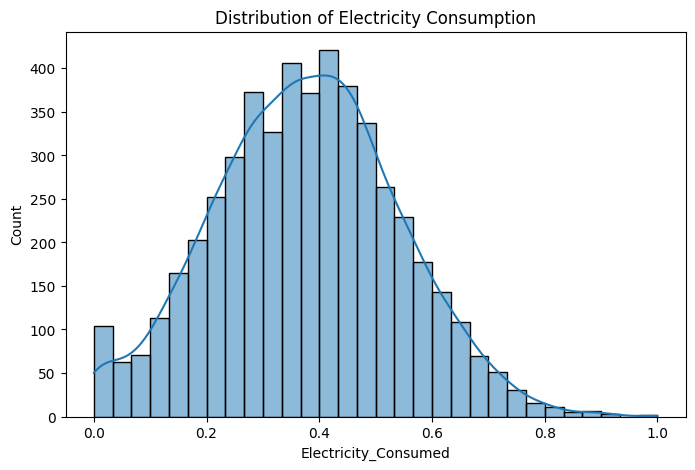

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Electricity_Consumed"], bins=30, kde=True)
plt.title("Distribution of Electricity Consumption")
plt.show()

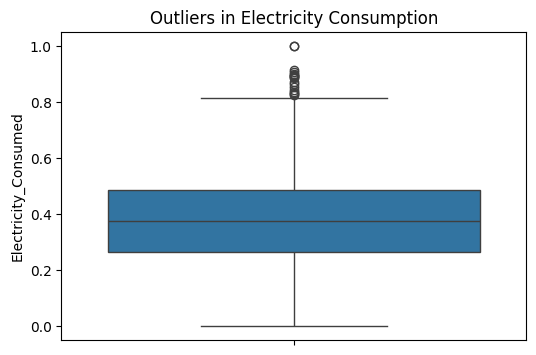

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Electricity_Consumed"])
plt.title("Outliers in Electricity Consumption")
plt.show()

In [ ]:
df['Difference'] = df['Electricity_Consumed'] - df['Avg_Past_Consumption']
df['Consumption_Ratio'] = df['Electricity_Consumed'] / (df['Avg_Past_Consumption'] + 1e-6)
df['Consumption_Change_Percentage'] = (
    (df['Difference'] / (df['Avg_Past_Consumption'] + 1e-6)) * 100
)
df['Year_Month'] = df['Timestamp'].dt.to_period('M')
df['Monthly_Average_Consumption'] = df.groupby('Year_Month')['Electricity_Consumed'].transform('mean')
df['Consumption_Standard_Deviation'] = df.groupby('Year_Month')['Electricity_Consumed'].transform('std')
df = df.drop(columns=['Year_Month'])
df = df.dropna().reset_index(drop=True)
df.to_csv('smart_meter_features_fixed.csv', index=False)

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
data = df.copy()

encoder = LabelEncoder()
data["Anomaly_Label"] = encoder.fit_transform(data["Anomaly_Label"])

X = data.drop(["Timestamp", "Anomaly_Label"], axis=1)

y = data["Anomaly_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
RF= pd.DataFrame({

    "Model":[
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, rf_pred)
    ],

    "Precision":[
        precision_score(y_test, rf_pred)
    ],

    "Recall":[
        recall_score(y_test, rf_pred)
    ],

    "F1-Score":[
        f1_score(y_test, rf_pred)
    ]

})

RF.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.989,0.989572,0.998947,0.994238


In [ ]:
print("Random Forest")
print(classification_report(y_test, rf_pred))
print("Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.98      0.80      0.88        50
           1       0.99      1.00      0.99       950

    accuracy                           0.99      1000
   macro avg       0.98      0.90      0.94      1000
weighted avg       0.99      0.99      0.99      1000

Accuracy: 0.989


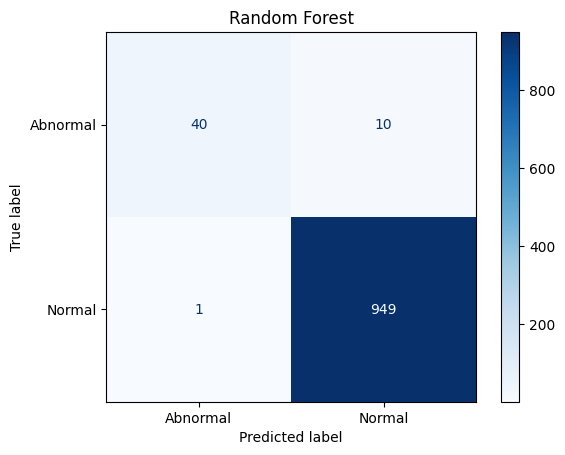

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=encoder.classes_,
    cmap="Blues"
)
plt.title("Random Forest")
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

/tmp/ipykernel_1245/938317127.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


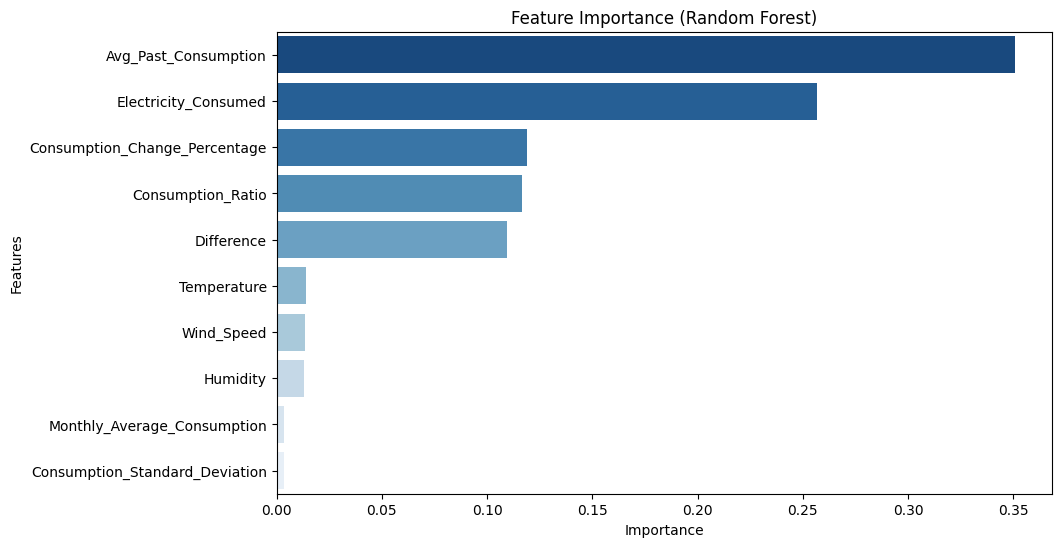

In [ ]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="Blues_r"
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

In [ ]:
import joblib
joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")

print(" Model and Label Encoder saved successfully!")


 Model and Label Encoder saved successfully!


In [ ]:
import joblib

rf = joblib.load("random_forest_model.pkl")
encoder = joblib.load("label_encoder.pkl")

def predict_electricity_theft(
    electricity_consumed,
    temperature,
    humidity,
    avg_past_consumption,
    monthly_average_consumption,
    consumption_standard_deviation
):

    difference = electricity_consumed - avg_past_consumption

    consumption_ratio = electricity_consumed / (avg_past_consumption + 1e-6)

    consumption_change_percentage = (
        difference / (avg_past_consumption + 1e-6)
    ) * 100


In [ ]:
def predict_electricity_theft(electricity_consumed, temperature, humidity, avg_past_consumption, difference, consumption_ratio, consumption_change_percentage, monthly_average_consumption, consumption_standard_deviation):
    input_data = pd.DataFrame([{
        "Electricity_Consumed": electricity_consumed,
        "Temperature": temperature,
        "Humidity": humidity,
        "Avg_Past_Consumption": avg_past_consumption,
        "Difference": difference,
        "Consumption_Ratio": consumption_ratio,
        "Consumption_Change_Percentage": consumption_change_percentage,
        "Monthly_Average_Consumption": monthly_average_consumption,
        "Consumption_Standard_Deviation": consumption_standard_deviation
    }])

    print(X.columns.tolist())
    prediction = rf.predict(input_data)[0]
    confidence = rf.predict_proba(input_data).max()
    prediction_label = encoder.inverse_transform([prediction])[0]

    return prediction_label, confidence

In [ ]:
FEATURES = [
    "Electricity_Consumed",
    "Temperature",
    "Humidity",
    "Avg_Past_Consumption",
    "Difference",
    "Consumption_Ratio",
    "Consumption_Change_Percentage",
    "Monthly_Average_Consumption",
    "Consumption_Standard_Deviation"
]

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import joblib
import os
import base64
from datetime import datetime


try:
    rf_model = joblib.load("random_forest_model.pkl")
    encoder = joblib.load("label_encoder.pkl")
    model_loaded = True
except Exception:
    model_loaded = False

def get_base64_image(image_path):
    if os.path.exists(image_path):
        with open(image_path, "rb") as img_file:
            return base64.b64encode(img_file.read()).decode('utf-8')
    return ""

bg_b64 = get_base64_image("background.jpg")
logo_b64 = get_base64_image("logo.jpg")

TRANSLATIONS = {
    "English": {
        "dir": "ltr",
        "hero_title": "AI Electricity Theft<br>Detection System",
        "hero_sub": "Smart Analysis • Accurate Assessment • Safe Decisions",
        "select_lang": "Select Language",
        "continue_btn": "Continue ➔",
        "disclaimer": "This system supports decision-making and does not replace official inspection procedures.",
        "p2_title": "Consumer Information",
        "p2_sub": "Please enter the consumer and environmental data",
        "consumer_num": "Consumer ID",
        "temp": "Temperature (°C)",
        "monthly_cons": "Monthly Consumption (kWh)",
        "hist_avg": "Historical Average (kWh)",
        "alert": "All fields are required for accurate analysis.",
        "analyze_btn": "Analyze ➔",
        "placeholder_id": "e.g. EG-2025-000124",
        "report_title": "Assessment Report",
        "another_btn": "Analyze Another Consumer",

        # Labels
        "assessment_result": "Assessment Result",
        "prediction_confidence": "Prediction Confidence",
        "consumption_comparison": "Consumption Comparison",
        "difference_from_normal": "Difference from Normal Usage",
        "analysis_summary": "Analysis Summary",
        "next_recommended_step": "Next Recommended Step",
        "important_notice": "Important Notice",
        "legal_text": "This assessment is generated by AI to support decision-making. Final actions must always follow official field inspection procedures.",
        "print_btn": "Print Report",
        "weather_context_title": "Weather Context",

        # Risk Levels
        "lvl_normal": "NORMAL",
        "lvl_review": "NEEDS REVIEW",
        "lvl_inspection": "INSPECTION REQUIRED",
        "lvl_urgent": "URGENT INVESTIGATION",

        # Descriptions
        "exp_normal": "Consumption is normal and aligns with historical usage patterns. No abnormal deviations detected.",
        "exp_review": "Minor deviation detected. Further review is recommended to verify operational status.",
        "exp_inspection": "Significant deviation detected. On-site technical inspection is required to inspect the meter and wiring.",
        "exp_urgent": "Critical anomaly detected far beyond operational ranges. Urgent investigation is required for potential tampering.",

        # Actions
        "proc_normal": ["• Routine monitoring only."],
        "proc_review": ["• Review billing history.", "• Perform remote meter check.", "• Schedule technical inspection if needed."],
        "proc_inspection": ["• Dispatch technical inspection team.", "• Check physical meter seals.", "• Verify electrical wiring integrity."],
        "proc_urgent": ["• Immediate urgent field investigation.", "• Collect physical evidence.", "• Initiate legal procedures if tampering is confirmed."],

        # Weather Context Texts
        "weather_hot": "High outdoor temperature may have contributed to increased electricity consumption due to cooling appliances.",
        "weather_cold": "Cold weather may have increased electricity usage because of heating appliances.",
        "weather_none": "Weather conditions do not fully explain the detected consumption pattern."
    },
    "العربية": {
        "dir": "rtl",
        "hero_title": "نظام الذكاء الاصطناعي<br>لكشف سرقات الكهرباء",
        "hero_sub": "تحليل ذكي • تقييم دقيق • قرارات آمنة",
        "select_lang": "اختر اللغة",
        "continue_btn": "متابعة ⬅️",
        "disclaimer": "هذا النظام يدعم اتخاذ القرار ولا يحل محل إجراءات التفتيش الرسمية.",
        "p2_title": "بيانات المستهلك",
        "p2_sub": "يرجى إدخال البيانات البيئية والاستهلاكية للمستهلك",
        "consumer_num": "رقم المستهلك",
        "temp": "درجة الحرارة (°م)",
        "monthly_cons": "الاستهلاك الشهري (كيلوواط)",
        "hist_avg": "المتوسط التاريخي (كيلوواط)",
        "alert": "جميع الحقول مطلوبة للحصول على تحليل دقيق.",
        "analyze_btn": "تحليل ⬅️",
        "placeholder_id": "مثال: EG-2025-000124",
        "report_title": "تقرير التقييم النهائي",
        "another_btn": "تحليل مستهلك آخر",

        # Labels
        "assessment_result": "نتيجة التقييم",
        "prediction_confidence": "مستوى ثقة التنبؤ",
        "consumption_comparison": "مقارنة الاستهلاك",
        "difference_from_normal": "نسبة الاختلاف عن المعتاد",
        "analysis_summary": "ملخص التحليل",
        "next_recommended_step": "الخطوة التالية الموصى بها",
        "important_notice": "تنبيه هام",
        "legal_text": "تم إنشاء هذا التقييم بواسطة الذكاء الاصطناعي لدعم اتخاذ القرار. يجب أن تخضع الإجراءات النهائية دائماً لإجراءات التفتيش الميداني الرسمية.",
        "print_btn": "طباعة التقرير",
        "weather_context_title": "سياق الظروف الجوية",

        # Risk Levels
        "lvl_normal": "طبيعي (NORMAL)",
        "lvl_review": "يحتاج مراجعة (NEEDS REVIEW)",
        "lvl_inspection": "يتطلب تفتيش (INSPECTION REQUIRED)",
        "lvl_urgent": "تحقيق عاجل (URGENT INVESTIGATION)",

        # Descriptions
        "exp_normal": "الاستهلاك طبيعي ومتوافق تماماً مع النمط التاريخي للمستهلك. لا توجد أي انحرافات مشتبه بها.",
        "exp_review": "لوحظ وجود اختلاف بسيط عن الاستهلاك المعتاد، يوصى بمراجعة السجلات والتأكد من الحالة التشغيلية.",
        "exp_inspection": "لوحظ وجود اختلاف كبير وغير عادي في الاستهلاك، يتطلب الأمر إجراء تفتيش فني ميداني وفحص التوصيلات.",
        "exp_urgent": "الحالة شديدة الخطورة وتظهر انحرافاً حرجاً خارج نطاق التشغيل المقبول، تتطلب تحقيقاً ميدانياً عاجلاً.",

        # Actions
        "proc_normal": ["• متابعة دورية روتينية فقط."],
        "proc_review": ["• مراجعة سجل الاستهلاك السابق.", "• إجراء فحص للعداد عن بُعد.", "• جدولة فحص فني إذا لزم الأمر."],
        "proc_inspection": ["• إرسال فريق تفتيش فني للموقع.", "• فحص سلامة أختام العداد.", "• التحقق من سلامة التوصيلات الكهربائية."],
        "proc_urgent": ["• إرسال فريق تحقيق ميداني عاجل.", "• توثيق وتسجيل الأدلة الميدانية.", "• اتخاذ الإجراءات القانونية المتبعة حال ثبات التلاعب."],

        # Weather Context Texts
        "weather_hot": "ارتفاع درجة الحرارة الخارجية قد يكون سبباً مشاركاً في زيادة الاستهلاك نتيجة استخدام أجهزة التبريد.",
        "weather_cold": "انخفاض درجة الحرارة قد يكون سبباً مشاركاً في زيادة الاستهلاك نتيجة استخدام أجهزة التدفئة.",
        "weather_none": "الظروف الجوية الحالية لا تفسر نمط الاستهلاك ورصد الانحراف بالكامل."
    }
}

custom_css = f"""
.gradio-container {{
    background: url("data:image/jpg;base64,{bg_b64}") no-repeat center center fixed !important;
    background-size: cover !important;
    font-family: 'Inter', -apple-system, BlinkMacSystemFont, sans-serif !important;
    min-height: 100vh;
}}
footer {{ visibility: hidden; }}

.top-header {{
    display: flex; align-items: center; gap: 12px; padding: 20px 40px;
}}
.header-title {{ color: #ffffff; font-weight: 700; font-size: 20px; margin: 0; }}
.header-subtitle {{ color: #b3d4ff; font-size: 13px; margin: 0; }}

.hero-title {{
    color: #0b1b3d; font-size: 38px; font-weight: 800; text-align: center; margin-top: 10px; margin-bottom: 5px;
}}
.hero-sub {{
    color: #1e3a8a; font-size: 16px; font-weight: 600; text-align: center; margin-bottom: 25px;
}}

.lang-card {{
    background: rgba(255, 255, 255, 0.92) !important;
    backdrop-filter: blur(20px) !important;
    border-radius: 24px !important; padding: 35px 40px !important;
    width: 420px !important; margin: 0 auto !important;
    box-shadow: 0 20px 40px rgba(0, 82, 204, 0.15) !important;
    border: 1px solid rgba(255, 255, 255, 0.6) !important;
}}

.primary-blue-btn button {{
    background: #0052cc !important; color: white !important;
    font-size: 16px !important; font-weight: 600 !important;
    border-radius: 12px !important; padding: 12px !important;
    width: 100% !important; border: none !important;
    box-shadow: 0 4px 12px rgba(0, 82, 204, 0.3) !important;
}}

.footer-disclaimer {{
    text-align: center; color: #ffffff; font-size: 13px; font-weight: 500;
    text-shadow: 0 2px 4px rgba(0,0,0,0.6); margin-top: 40px; margin-bottom: 20px;
}}

.p2-card {{
    background: rgba(255, 255, 255, 0.95) !important;
    backdrop-filter: blur(15px) !important;
    border-radius: 20px !important; padding: 30px !important;
    box-shadow: 0 10px 30px rgba(0, 0, 0, 0.08) !important;
    border: 1px solid rgba(255, 255, 255, 0.8) !important;
}}

.p2-title {{ color: #0b1b3d; font-size: 28px; font-weight: 800; margin-bottom: 4px; }}
.p2-sub {{ color: #5e6c84; font-size: 14px; margin-bottom: 25px; }}

.info-alert {{
    background: #e6f0ff; border: 1px solid #b3d4ff; border-radius: 10px;
    padding: 12px 16px; color: #0052cc; font-size: 13px; font-weight: 500;
    margin-top: 15px; margin-bottom: 20px;
}}

.report-grid {{ display: grid; grid-template-columns: repeat(4, 1fr); gap: 15px; margin-bottom: 20px; }}
.report-card {{
    background: #ffffff; border-radius: 16px; padding: 20px;
    box-shadow: 0 4px 15px rgba(0,0,0,0.05); border: 1px solid #eaeeef; text-align: center;
}}

.metric-title {{ color: #5e6c84; font-size: 13px; font-weight: 600; margin-bottom: 10px; }}
.metric-val {{ font-size: 18px; font-weight: 800; color: #0b1b3d; }}
.metric-sub {{ font-size: 11px; color: #6b778c; margin-top: 6px; font-weight: 500; }}

.val-crit {{ color: #b71c1c !important; }}
.val-high {{ color: #de350b !important; }}
.val-med {{ color: #ffab00 !important; }}
.val-low {{ color: #36b37e !important; }}

.legal-box {{
    background: #f8fafc; border: 1px solid #cbd5e1; border-radius: 14px;
    padding: 16px; color: #334155; font-size: 12px; line-height: 1.6; margin-top: 15px;
}}

.info-banner {{
    background: #f1f5f9; border-radius: 12px; padding: 14px 18px; margin-bottom: 20px;
    border: 1px solid #e2e8f0; display: flex; flex-wrap: wrap; gap: 20px; justify-content: space-between;
}}
.info-banner-item {{ font-size: 13px; color: #334155; }}
.info-banner-item b {{ color: #0f172a; }}

.rtl-mode {{ direction: rtl !important; text-align: right !important; }}
.ltr-mode {{ direction: ltr !important; text-align: left !important; }}
.no-label label span {{ display: none !important; }}

@media print {{
    .no-print {{ display: none !important; }}
    .gradio-container {{ background: white !important; }}
}}
"""

with gr.Blocks(css=custom_css, title="PowerGuard AI") as app:

    logo_src = f"data:image/jpg;base64,{logo_b64}" if logo_b64 else ""
    logo_html_content = f'<img src="{logo_src}" style="width:45px; height:45px; border-radius:50%;">' if logo_b64 else '<div style="font-size:24px;">⚡</div>'

    current_lang_state = gr.State("English")

    header_static_html = f"""
    <div class="top-header">
        {logo_html_content}
        <div>
            <div class="header-title">Electricity Company</div>
            <div class="header-subtitle">Powering a Better Future — PowerGuard AI</div>
        </div>
    </div>
    """

    # Page 1
    with gr.Column(elem_id="page1_view", visible=True) as page1:
        gr.HTML(header_static_html)
        hero_html = gr.HTML()
        with gr.Column(elem_classes="lang-card"):
            select_lang_title = gr.HTML()
            with gr.Row():
                btn_en = gr.Button("🌐 English", size="sm")
                btn_ar = gr.Button("🇪🇬 العربية", size="sm")
            continue_btn = gr.Button(elem_classes="primary-blue-btn")
        disclaimer_html = gr.HTML()

    # Page 2
    with gr.Column(elem_id="page2_view", visible=False) as page2:
        with gr.Row():
            gr.HTML(header_static_html, scale=4)
            with gr.Column(scale=1, min_width=150):
                p2_lang_dropdown = gr.Dropdown(choices=["English", "العربية"], value="English", show_label=False, container=False, elem_classes="no-label")

        with gr.Column(elem_classes="p2-card") as p2_card_container:
            p2_titles_html = gr.HTML()
            with gr.Row():
                consumer_num = gr.Textbox(label="Consumer ID", value="EG-2025-000124", interactive=True)
                temp = gr.Number(label="Temperature (°C)", value=28.5, interactive=True)
            with gr.Row():
                monthly_cons = gr.Number(label="Monthly Consumption (kWh)", value=305, interactive=True)
                hist_avg = gr.Number(label="Historical Average (kWh)", value=296, interactive=True)

            alert_html = gr.HTML()
            analyze_btn = gr.Button(elem_classes="primary-blue-btn")

    # Page 3
    with gr.Column(elem_id="page3_view", visible=False) as page3:
        with gr.Row(elem_classes="no-print"):
            gr.HTML(header_static_html, scale=3)
            with gr.Row(scale=2):
                p3_another_btn = gr.Button(elem_classes="primary-blue-btn")
                p3_lang_dropdown = gr.Dropdown(choices=["English", "العربية"], value="English", show_label=False, container=False, elem_classes="no-label")

        with gr.Column(elem_classes="p2-card") as p3_card_container:
            p3_top_info = gr.HTML()
            consumer_banner_html = gr.HTML()
            metrics_cards_html = gr.HTML()
            with gr.Row():
                with gr.Column(scale=1): summary_box_html = gr.HTML()
                with gr.Column(scale=1): proc_box_html = gr.HTML()

            legal_box_html = gr.HTML()

            with gr.Row(elem_classes="no-print"):
                print_btn = gr.Button("Print Report", elem_classes="primary-blue-btn")

    def update_ui_language(lang_selection):
        lang_key = "العربية" if "عربية" in str(lang_selection) or "العربية" in str(lang_selection) else "English"
        t = TRANSLATIONS[lang_key]
        align_class = "rtl-mode" if t["dir"] == "rtl" else "ltr-mode"

        hero = f"<div class='hero-title'>{t['hero_title']}</div><div class='hero-sub'>{t['hero_sub']}</div>"
        disclaimer = f"<div class='footer-disclaimer'><span>{t['disclaimer']}</span></div>"
        select_title = f"<h3 style='text-align:center;'>{t['select_lang']}</h3>"
        p2_titles = f"<div class='{align_class}'><div class='p2-title'>{t['p2_title']}</div><div class='p2-sub'>{t['p2_sub']}</div></div>"
        alert = f"<div class='info-alert {align_class}'><span>{t['alert']}</span></div>"
        dropdown_val = "العربية" if lang_key == "العربية" else "English"

        return (
            lang_key, hero, select_title, t["continue_btn"], disclaimer, dropdown_val, dropdown_val, p2_titles,
            gr.update(label=t["consumer_num"], placeholder=t["placeholder_id"], elem_classes=align_class, interactive=True),
            gr.update(label=t["temp"], elem_classes=align_class, interactive=True),
            gr.update(label=t["monthly_cons"], elem_classes=align_class, interactive=True),
            gr.update(label=t["hist_avg"], elem_classes=align_class, interactive=True),
            alert, t["analyze_btn"], gr.update(elem_classes=align_class), t["another_btn"]
        )

    def generate_report(c_num, m_cons, h_avg, temp_val, lang_selection):
        lang_key = "العربية" if "عربية" in str(lang_selection) or "العربية" in str(lang_selection) else "English"
        t = TRANSLATIONS[lang_key]
        align_class = "rtl-mode" if t["dir"] == "rtl" else "ltr-mode"

        m_cons = float(m_cons) if m_cons else 0.0
        h_avg = float(h_avg) if h_avg and float(h_avg) > 0 else 1.0
        diff = m_cons - h_avg
        ratio = m_cons / h_avg
        pct_change = (diff / h_avg) * 100

        # --- حساب ثقة الموديل ---
        raw_prob = 0.50
        if model_loaded:
            try:
                input_df = pd.DataFrame([{
                    "Electricity_Consumed": m_cons, "Temperature": temp_val, "Humidity": 60,
                    "Avg_Past_Consumption": h_avg, "Difference": diff, "Consumption_Ratio": ratio,
                    "Consumption_Change_Percentage": pct_change, "Monthly_Average_Consumption": h_avg,
                    "Consumption_Standard_Deviation": 25.0
                }])
                if hasattr(rf_model, "feature_names_in_"):
                    input_df = input_df[rf_model.feature_names_in_]

                probs = rf_model.predict_proba(input_df)[0]
                theft_idx = 1
                if encoder:
                    classes = [str(c).lower() for c in encoder.classes_]
                    for idx, cls_name in enumerate(classes):
                        if "theft" in cls_name or "anomaly" in cls_name or cls_name == "1":
                            theft_idx = idx
                            break
                raw_prob = float(probs[theft_idx])
            except Exception:
                raw_prob = 0.85 if (ratio < 0.8 or ratio > 1.2) else 0.50
        else:
            raw_prob = 0.85 if (ratio < 0.8 or ratio > 1.2) else 0.50

        confidence_val = max(0.50, min(0.99, raw_prob))


        if ratio > 4.00 or ratio < 0.25:
            risk = t["lvl_urgent"]
            color_cls = "val-crit"
            main_color = "#b71c1c"
            exp_text = t["exp_urgent"]
            procs = t["proc_urgent"]
            est_risk_pct = 95
            active_lvl_code = "URGENT"
        elif (2.00 < ratio <= 4.00) or (0.25 <= ratio < 0.50):
            risk = t["lvl_inspection"]
            color_cls = "val-high"
            main_color = "#de350b"
            exp_text = t["exp_inspection"]
            procs = t["proc_inspection"]
            est_risk_pct = 75
            active_lvl_code = "INSPECTION"
        elif (1.20 < ratio <= 2.00) or (0.50 <= ratio < 0.80):
            risk = t["lvl_review"]
            color_cls = "val-med"
            main_color = "#ffab00"
            exp_text = t["exp_review"]
            procs = t["proc_review"]
            est_risk_pct = 45
            active_lvl_code = "REVIEW"
        else:
            risk = t["lvl_normal"]
            color_cls = "val-low"
            main_color = "#36b37e"
            exp_text = t["exp_normal"]
            procs = t["proc_normal"]
            est_risk_pct = 10
            active_lvl_code = "NORMAL"

        # --- تفسير الطقس ---
        if temp_val >= 35 and m_cons > h_avg:
            weather_text = t["weather_hot"]
        elif temp_val <= 15 and m_cons > h_avg:
            weather_text = t["weather_cold"]
        else:
            weather_text = t["weather_none"]

        # --- شريط مستويات المخاطر (Risk Scale) ---
        scale_levels = [
            ("NORMAL", t["lvl_normal"]),
            ("REVIEW", t["lvl_review"]),
            ("INSPECTION", t["lvl_inspection"]),
            ("URGENT", t["lvl_urgent"])
        ]

        scale_html = '<div style="display: flex; gap: 8px; margin: 15px 0; background: rgba(0,0,0,0.03); padding: 8px; border-radius: 8px;">'
        for code, label_name in scale_levels:
            is_active = (code == active_lvl_code)
            active_style = f"background: {main_color}; color: #ffffff; font-weight: bold; box-shadow: 0 2px 6px rgba(0,0,0,0.15);" if is_active else "background: rgba(255,255,255,0.7); color: #5e6c84;"
            scale_html += f'<div style="flex: 1; text-align: center; padding: 8px 4px; border-radius: 6px; font-size: 11px; {active_style}">{label_name}</div>'
        scale_html += '</div>'

        now_str = datetime.now().strftime("%d %b %Y | %I:%M %p")

        # 1. Header
        p3_top = f"""
        <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:15px;" class="{align_class}">
            <div>
                <h2 style="color:#0b1b3d; margin:0; font-size:24px; font-weight:800;">{t['report_title']}</h2>
                <span style="color:#5e6c84; font-size:12px;">Generated: {now_str}</span>
            </div>
        </div>
        """

        # 2. Consumer Information Overview Banner
        consumer_banner = f"""
        <div class="info-banner {align_class}">
            <div class="info-banner-item"><b>{t['consumer_num']}:</b> {c_num}</div>
            <div class="info-banner-item"><b>{t['monthly_cons']}:</b> {m_cons:.1f} kWh</div>
            <div class="info-banner-item"><b>{t['hist_avg']}:</b> {h_avg:.1f} kWh</div>
            <div class="info-banner-item"><b>{t['temp']}:</b> {temp_val}°C</div>
        </div>
        """

        # 3. Grid Metrics Cards
        metrics = f"""
        <div class="report-grid {align_class}">
            <div class="report-card">
                <div class="metric-title">{t['assessment_result']}</div>
                <div class="metric-val {color_cls}">{risk}</div>
                <div class="metric-sub">Estimated Risk: <b>{est_risk_pct}%</b></div>
            </div>
            <div class="report-card">
                <div class="metric-title">{t['prediction_confidence']}</div>
                <div class="metric-val">{int(confidence_val * 100)}%</div>
                <div class="metric-sub">Prediction Confidence: <b>{int(confidence_val * 100)}%</b></div>
            </div>
            <div class="report-card">
                <div class="metric-title">{t['consumption_comparison']}</div>
                <div class="metric-val" style="font-size:15px;">{m_cons:.0f} / {h_avg:.0f} <span style="font-size:11px; font-weight:normal;">kWh</span></div>
                <div class="metric-sub">Current vs Historical</div>
            </div>
            <div class="report-card">
                <div class="metric-title">{t['difference_from_normal']}</div>
                <div class="metric-val {color_cls}">{pct_change:+.1f}%</div>
                <div class="metric-sub">Ratio: {ratio:.2f}x</div>
            </div>
        </div>
        {scale_html}
        """

        # 4. Summary & Weather Box
        summary_box = f"""
        <div style="background:#f8fafc; border-radius:12px; padding:18px; height:100%; border:1px solid #e2e8f0;" class="{align_class}">
            <h4 style="color:#0b1b3d; margin-top:0; margin-bottom:8px; font-size:15px;">{t['analysis_summary']}</h4>
            <p style="color:#334155; font-size:13px; line-height:1.6; margin:0;">{exp_text}</p>
            <hr style="border:none; border-top:1px solid #e2e8f0; margin:14px 0;">
            <h5 style="color:#0052cc; margin:0 0 6px 0; font-size:13px;">{t['weather_context_title']}</h5>
            <p style="color:#5e6c84; font-size:12px; margin:0; line-height:1.5;">{weather_text}</p>
        </div>
        """

        # 5. Next Recommended Step Box
        proc_list_html = "".join([f"<p style='color:#334155; font-size:13px; margin:6px 0;'>{p}</p>" for p in procs])
        proc_box = f"""
        <div style="background:#f8fafc; border-radius:12px; padding:18px; height:100%; border:1px solid #e2e8f0;" class="{align_class}">
            <h4 style="color:#0b1b3d; margin-top:0; margin-bottom:8px; font-size:15px;">{t['next_recommended_step']}</h4>
            {proc_list_html}
        </div>
        """

        # 6. Important Notice Box
        legal_box = f"""
        <div class="legal-box {align_class}">
            <b>{t['important_notice']}:</b> {t['legal_text']}
        </div>
        """

        return p3_top, consumer_banner, metrics, summary_box, proc_box, legal_box


    # --- ربط الأحداث (Event Handlers) ---
    btn_en.click(fn=lambda: update_ui_language("English"), outputs=[current_lang_state, hero_html, select_lang_title, continue_btn, disclaimer_html, p2_lang_dropdown, p3_lang_dropdown, p2_titles_html, consumer_num, temp, monthly_cons, hist_avg, alert_html, analyze_btn, p3_card_container, p3_another_btn])
    btn_ar.click(fn=lambda: update_ui_language("العربية"), outputs=[current_lang_state, hero_html, select_lang_title, continue_btn, disclaimer_html, p2_lang_dropdown, p3_lang_dropdown, p2_titles_html, consumer_num, temp, monthly_cons, hist_avg, alert_html, analyze_btn, p3_card_container, p3_another_btn])

    p2_lang_dropdown.change(fn=update_ui_language, inputs=[p2_lang_dropdown], outputs=[current_lang_state, hero_html, select_lang_title, continue_btn, disclaimer_html, p2_lang_dropdown, p3_lang_dropdown, p2_titles_html, consumer_num, temp, monthly_cons, hist_avg, alert_html, analyze_btn, p3_card_container, p3_another_btn])
    p3_lang_dropdown.change(fn=update_ui_language, inputs=[p3_lang_dropdown], outputs=[current_lang_state, hero_html, select_lang_title, continue_btn, disclaimer_html, p2_lang_dropdown, p3_lang_dropdown, p2_titles_html, consumer_num, temp, monthly_cons, hist_avg, alert_html, analyze_btn, p3_card_container, p3_another_btn])

    continue_btn.click(fn=lambda: (gr.update(visible=False), gr.update(visible=True)), outputs=[page1, page2])
    p3_another_btn.click(fn=lambda: (gr.update(visible=False), gr.update(visible=True)), outputs=[page3, page2])

    analyze_btn.click(
        fn=lambda c, m, h, t, l: (
            gr.update(visible=False),
            gr.update(visible=True),
            *generate_report(c, m, h, t, l)
        ),
        inputs=[consumer_num, monthly_cons, hist_avg, temp, current_lang_state],
        outputs=[page2, page3, p3_top_info, consumer_banner_html, metrics_cards_html, summary_box_html, proc_box_html, legal_box_html]
    )

    print_btn.click(fn=None, js="() => window.print()")


    app.load(fn=lambda: update_ui_language("English"), outputs=[current_lang_state, hero_html, select_lang_title, continue_btn, disclaimer_html, p2_lang_dropdown, p3_lang_dropdown, p2_titles_html, consumer_num, temp, monthly_cons, hist_avg, alert_html, analyze_btn, p3_card_container, p3_another_btn])

if __name__ == "__main__":
    app.launch()

/tmp/ipykernel_1245/1672898224.py:235: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, title="PowerGuard AI") as app:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7145fb643d4e11393d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
